In [4]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [5]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    project_dir = r'C:\Users\jmora\Documents\TFMDS'
    os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", project_dir in sys.path)

Directorio de trabajo: C:\Users\jmora\Documents\TFMDS
Python path incluye proyecto: True


In [6]:

import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [7]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  lag_ventas_1        625800 non-null  float64       
 12  lag_ventas_2        625800 non-null  fl

# LightGBM

- Determinar características utilizar FEATURES
- Descomponer serie en Train y Test
- Características a Normalizar/Estandarizar o codificar
- Crear modelos estimando hiperparámetros
- Valorar modelos




In [8]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [9]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM


# LightGBM global

In [10]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (LightGBM)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: LIGHTGBM GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")


print("\n🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA LIGHTGBM
# =====================================================

def objective_lgb(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt','dart']),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', -1, 12),  # -1 significa sin límite
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    model = lgb.LGBMRegressor(**params, random_state=42)

    # Entrenar con early stopping
    model.fit(
         X_tr, y_tr,
         eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(50)])
    
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse


# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...")
start_time = time.perf_counter()

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=40, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros LightGBM:")
print(study_lgb.best_params)

best_params = study_lgb.best_params.copy()
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': 42
})

best_lgb = lgb.LGBMRegressor(**best_params)

best_lgb.fit(X_train, y_train)

# Predicciones
y_train_pred = best_lgb.predict(X_train)
y_test_pred = best_lgb.predict(X_test)

# Calcular métricas
metricas_train_global = calcular_metricas(y_train, y_train_pred, 'LightGBM Global Train')
metricas_test_global = calcular_metricas(y_test, y_test_pred, 'LightGBM Global Test')

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_train_global, metricas_test_global])


[I 2025-11-28 13:07:42,468] A new study created in memory with name: no-name-3d4427d2-9c49-4901-8f15-b33f24eba0d4



🔍 MODELO 1: LIGHTGBM GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...

🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...


[I 2025-11-28 13:11:10,939] Trial 0 finished with value: 3.891019769018274 and parameters: {'boosting_type': 'dart', 'num_leaves': 102, 'n_estimators': 717, 'learning_rate': 0.0428190773345253, 'max_depth': 5, 'min_child_samples': 88, 'bagging_fraction': 0.8529373113995533, 'bagging_freq': 2, 'feature_fraction': 0.9197746712018882, 'reg_lambda': 2.7463093249182733, 'reg_alpha': 0.5846326372362994, 'min_split_gain': 0.33842951557483436}. Best is trial 0 with value: 3.891019769018274.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[375]	valid_0's rmse: 1.96929
Did not meet early stopping. Best iteration is:
[375]	valid_0's rmse: 1.96929


[I 2025-11-28 13:11:22,991] Trial 1 finished with value: 3.878100337248664 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 102, 'n_estimators': 376, 'learning_rate': 0.020631498406196387, 'max_depth': 6, 'min_child_samples': 95, 'bagging_fraction': 0.9139153624376175, 'bagging_freq': 7, 'feature_fraction': 0.7464879492152487, 'reg_lambda': 2.4554351268295274, 'reg_alpha': 0.44717941412999007, 'min_split_gain': 0.7553519343803962}. Best is trial 1 with value: 3.878100337248664.
[I 2025-11-28 13:11:58,738] Trial 2 finished with value: 3.941109739998114 and parameters: {'boosting_type': 'dart', 'num_leaves': 148, 'n_estimators': 582, 'learning_rate': 0.07910722595242656, 'max_depth': 1, 'min_child_samples': 79, 'bagging_fraction': 0.901997611479077, 'bagging_freq': 2, 'feature_fraction': 0.833206812798115, 'reg_lambda': 2.335011584466967, 'reg_alpha': 1.1387215931050503, 'min_split_gain': 0.1562640250437578}. Best is trial 1 with value: 3.878100337248664.
[I 2025-11-28 13:11:58,73

...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[466]	valid_0's rmse: 1.96625
Early stopping, best iteration is:
[466]	valid_0's rmse: 1.96625


[I 2025-11-28 13:55:53,558] Trial 38 finished with value: 3.8661375352206226 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 90, 'n_estimators': 1081, 'learning_rate': 0.020094163716590632, 'max_depth': 11, 'min_child_samples': 90, 'bagging_fraction': 0.9161909524079779, 'bagging_freq': 5, 'feature_fraction': 0.7493307018273049, 'reg_lambda': 1.6395952367059736, 'reg_alpha': 0.578438032254903, 'min_split_gain': 0.06610985897906752}. Best is trial 33 with value: 3.864606639038592.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[601]	valid_0's rmse: 1.96586
Early stopping, best iteration is:
[601]	valid_0's rmse: 1.96586


[I 2025-11-28 13:56:22,226] Trial 39 finished with value: 3.864592554024786 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 130, 'n_estimators': 1156, 'learning_rate': 0.015321756938161256, 'max_depth': 11, 'min_child_samples': 89, 'bagging_fraction': 0.9203123728304194, 'bagging_freq': 6, 'feature_fraction': 0.8597522967695996, 'reg_lambda': 2.287333149441989, 'reg_alpha': 0.6211960178548335, 'min_split_gain': 0.027371957905318822}. Best is trial 39 with value: 3.864592554024786.


✅ Optuna completado en 2919.76 segundos

🏆 Mejores hiperparámetros LightGBM:
{'boosting_type': 'gbdt', 'num_leaves': 130, 'n_estimators': 1156, 'learning_rate': 0.015321756938161256, 'max_depth': 11, 'min_child_samples': 89, 'bagging_fraction': 0.9203123728304194, 'bagging_freq': 6, 'feature_fraction': 0.8597522967695996, 'reg_lambda': 2.287333149441989, 'reg_alpha': 0.6211960178548335, 'min_split_gain': 0.027371957905318822}

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Global Test 1.5688 5.6171 2.3700 0.2670     49.65     144.56 0.7263    96.08
LightGBM Global Train 1.6100 5.7413 2.3961 0.2953     47.48     139.51 0.6944    93.12

🏆 Mejor modelo: LightGBM Global Test (RMSE: 2.3700)

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Global Test 1.5688 5.6171 2.3700 0.2670     49.65  

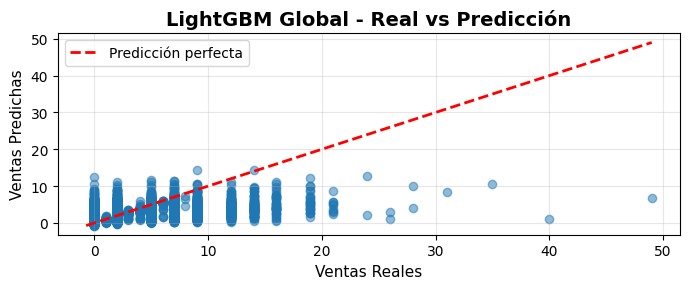

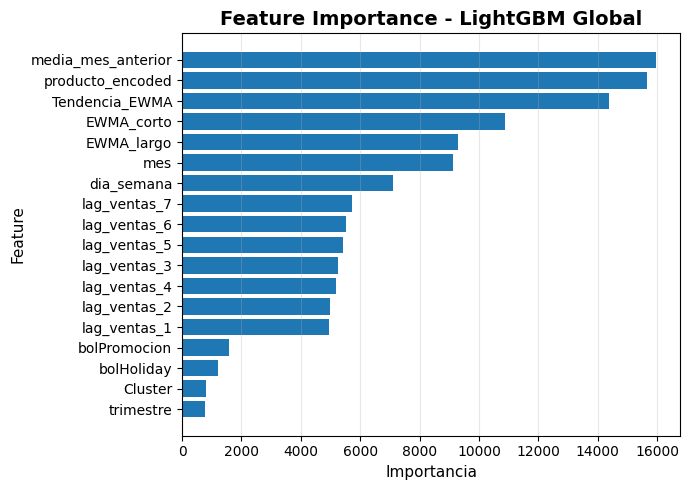

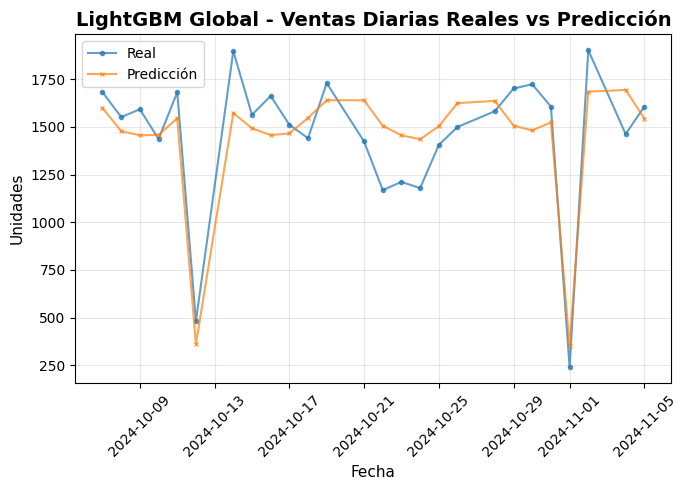

In [11]:

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]

grafico_scatter_prediccion(
    df=df_test_viz,
    col_real=TARGET,
    col_pred='prediccion',
    titulo='LightGBM Global - Real vs Predicción',
    figsize=(7, 3)
)

grafico_feature_importance(
    modelo=best_lgb,
    feature_names=FEATURES,
    top_n=len(FEATURES),
    titulo='Feature Importance - LightGBM Global',
    figsize=(7, 5)
)

# Crear dataframe con suma por día
df_daily = df_test_viz.copy()
df_daily['fecha'] = df_daily['idSecuencia'].dt.date
df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
grafico_real_vs_prediccion(
    df=df_daily_sum,
    col_real=TARGET,
    col_pred='prediccion',
    col_fecha='fecha',
    titulo='LightGBM Global - Ventas Diarias Reales vs Predicción',
    figsize=(7, 5)
)


# LightGBM por Cluster


🔍 MODELO 2: LIGHTGBM POR CLUSTER

🔄 Entrenando modelo para Cluster 0...
   ✓ MAE: 1.80 | RMSE: 2.55 | R²: 0.1166
   ✓ MAE: 1.80 | RMSE: 2.55 | R²: 0.1166


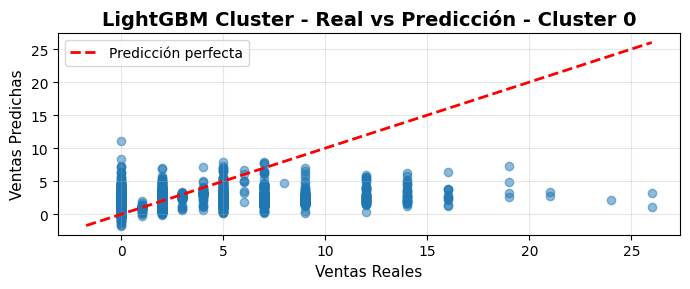

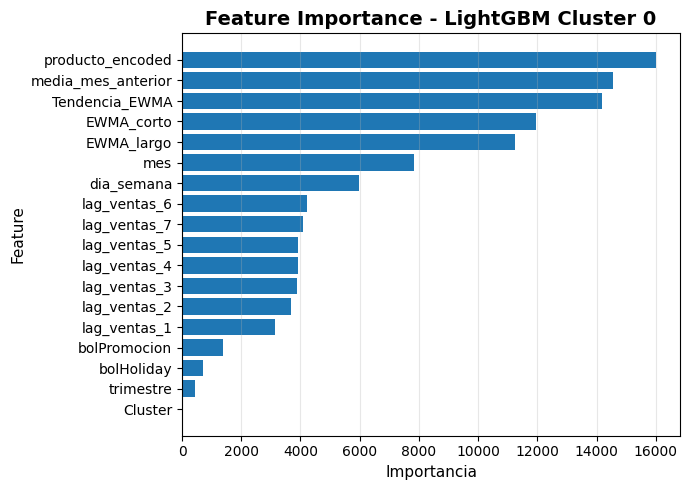

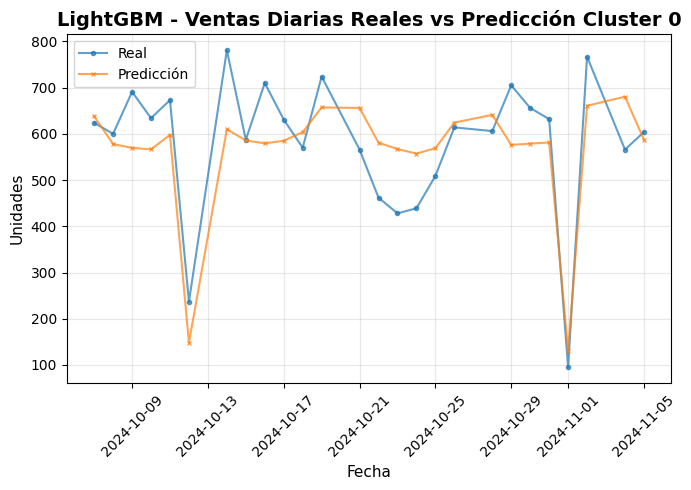


   📌 Producto representativo: 17 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.05
      Error abs medio:          1.80
      Error máximo:            24.85


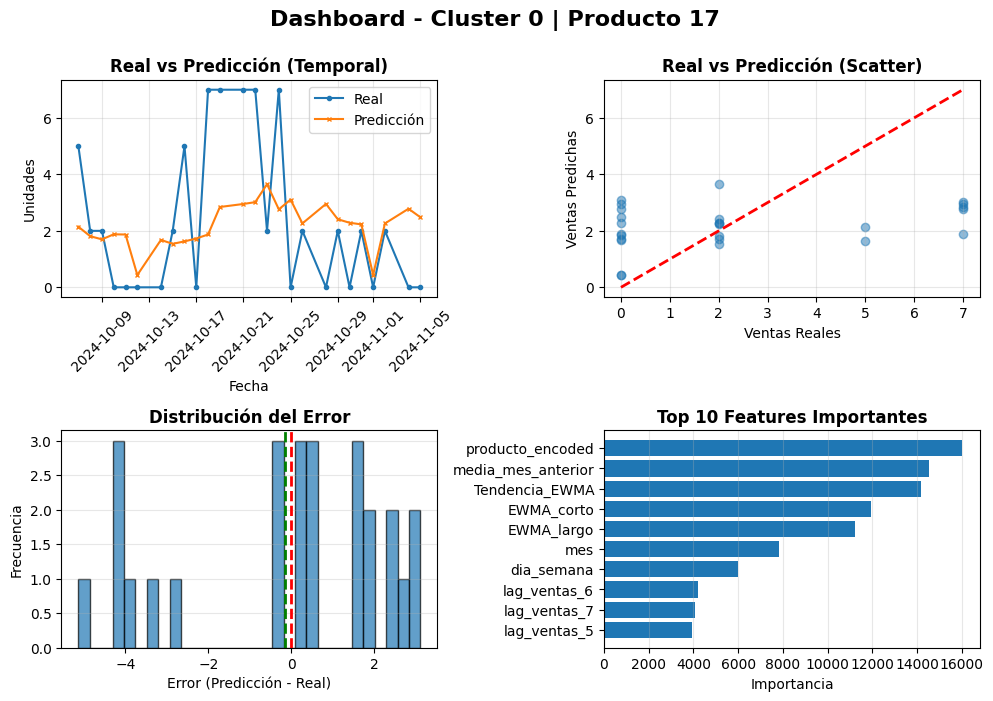


🔄 Entrenando modelo para Cluster 1...
   ✓ MAE: 2.80 | RMSE: 3.62 | R²: 0.1276
   ✓ MAE: 2.80 | RMSE: 3.62 | R²: 0.1276


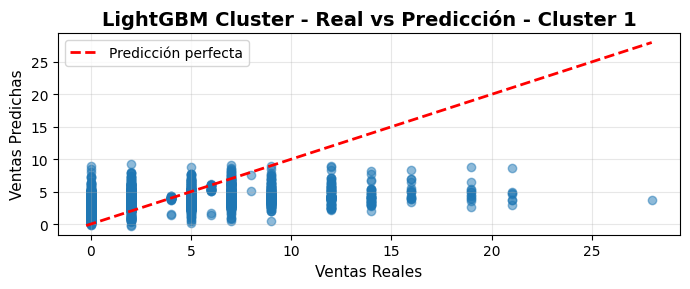

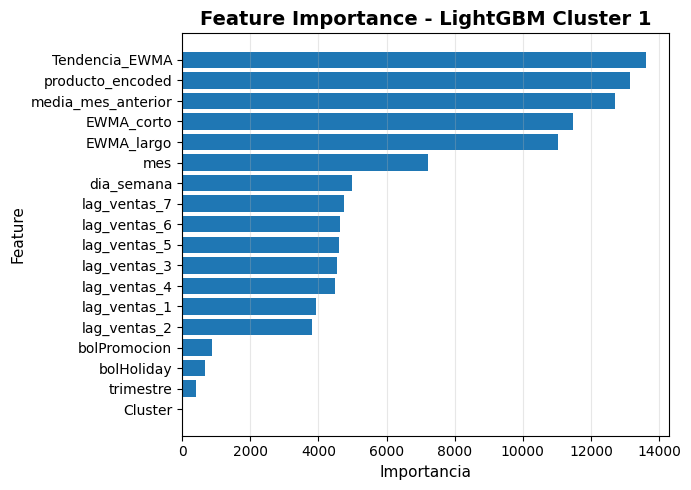

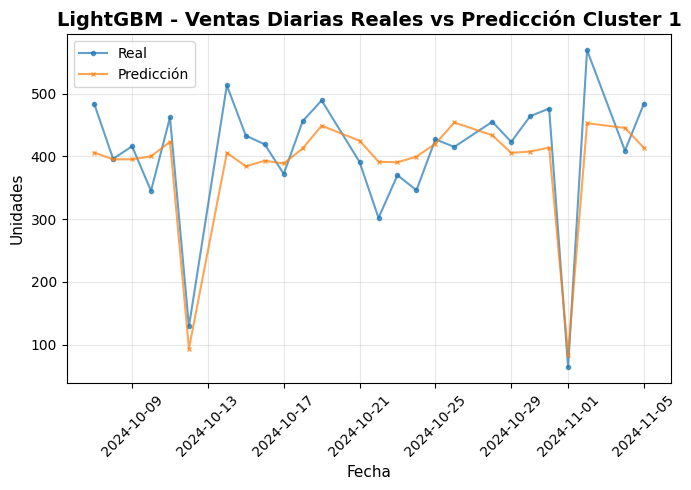


   📌 Producto representativo: 4 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.15
      Error abs medio:          2.80
      Error máximo:            24.30


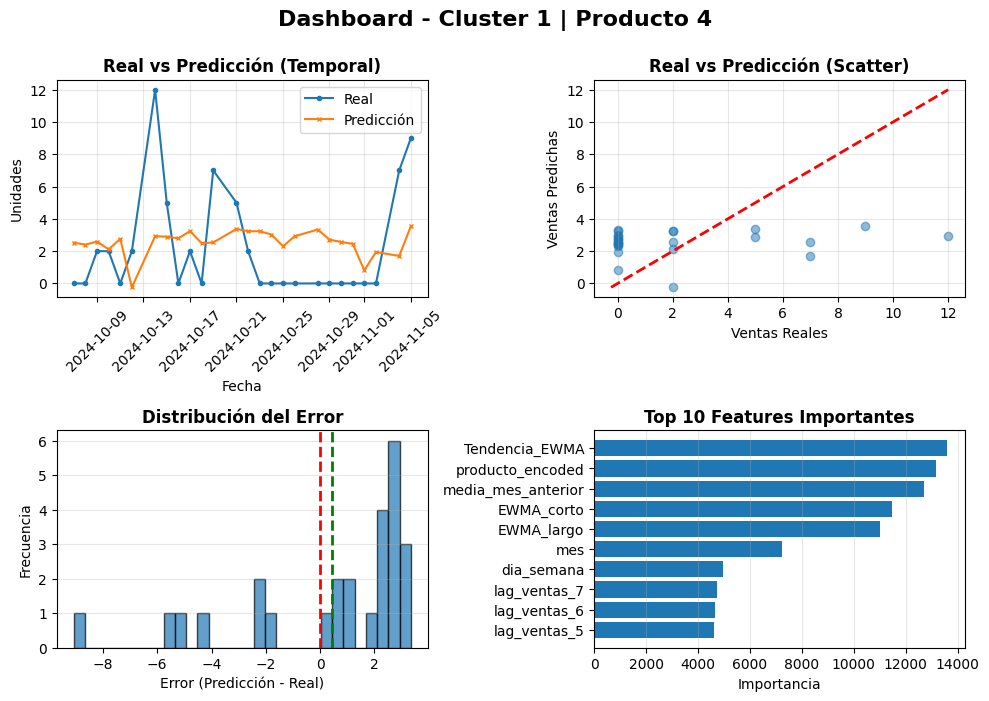


🔄 Entrenando modelo para Cluster 2...
   ✓ MAE: 3.72 | RMSE: 5.20 | R²: 0.1646
   ✓ MAE: 3.72 | RMSE: 5.20 | R²: 0.1646


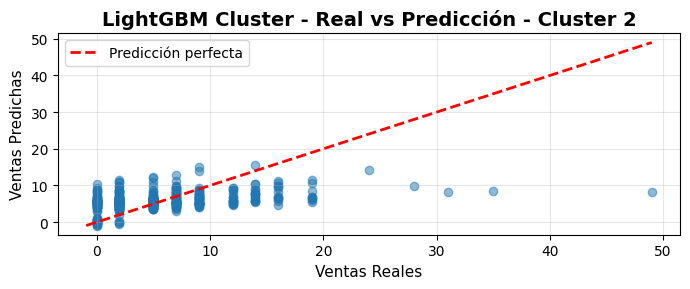

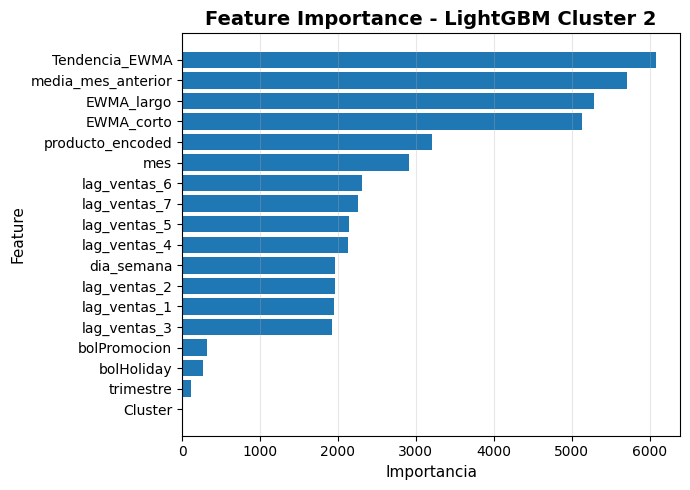

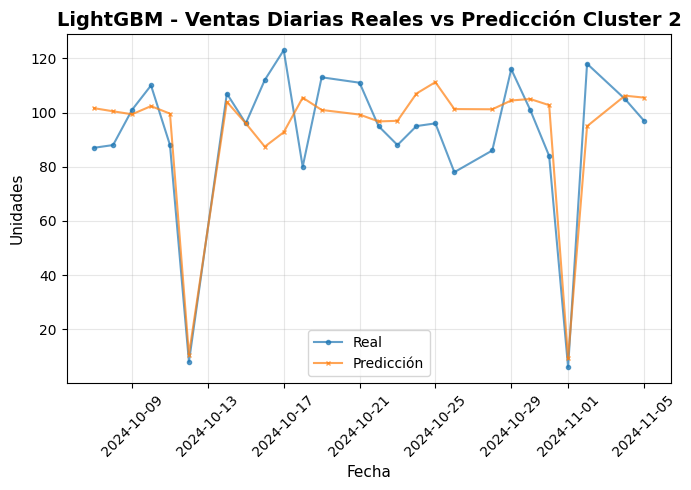


   📌 Producto representativo: 1 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.13
      Error abs medio:          3.72
      Error máximo:            40.75


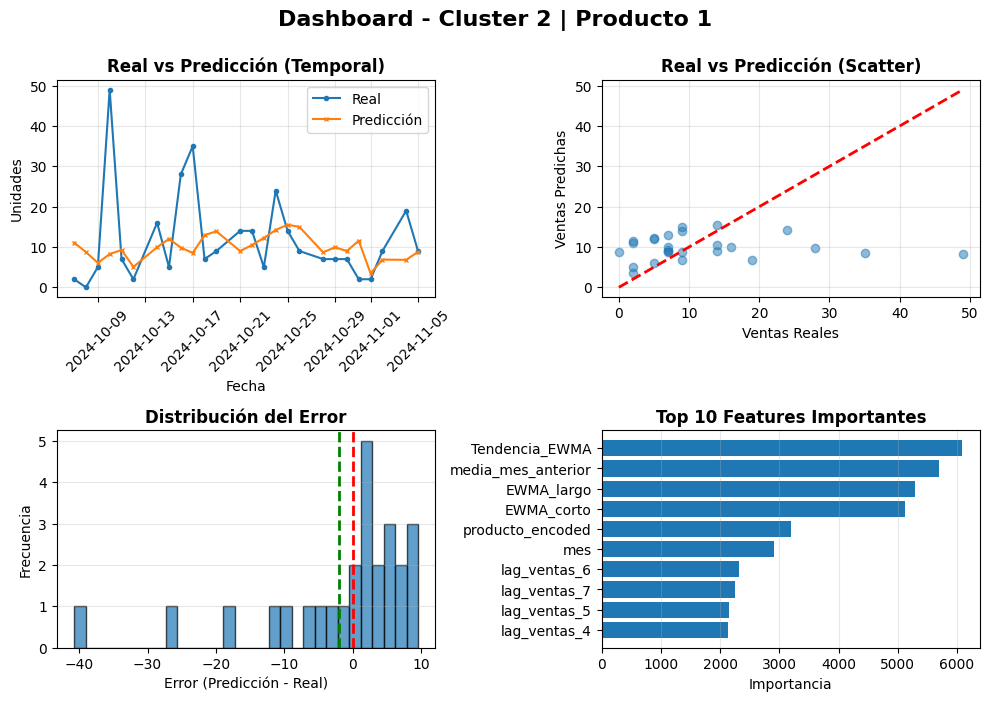


🔄 Entrenando modelo para Cluster 3...
   ✓ MAE: 1.08 | RMSE: 1.68 | R²: 0.0567
   ✓ MAE: 1.08 | RMSE: 1.68 | R²: 0.0567


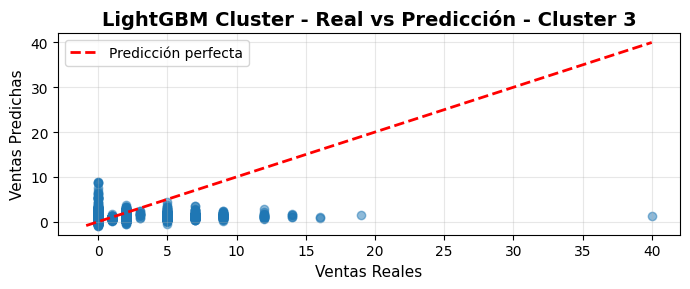

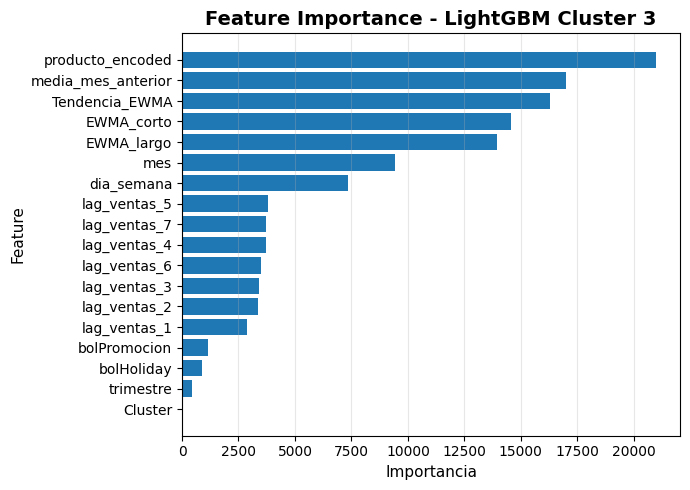

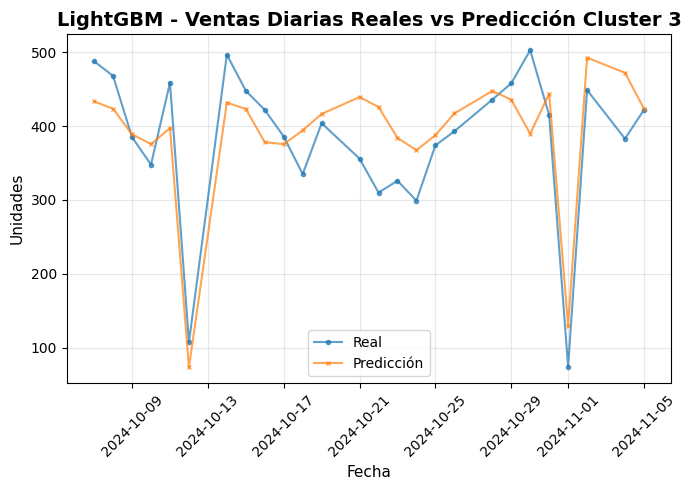


   📌 Producto representativo: 38 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.02
      Error abs medio:          1.09
      Error máximo:            38.69


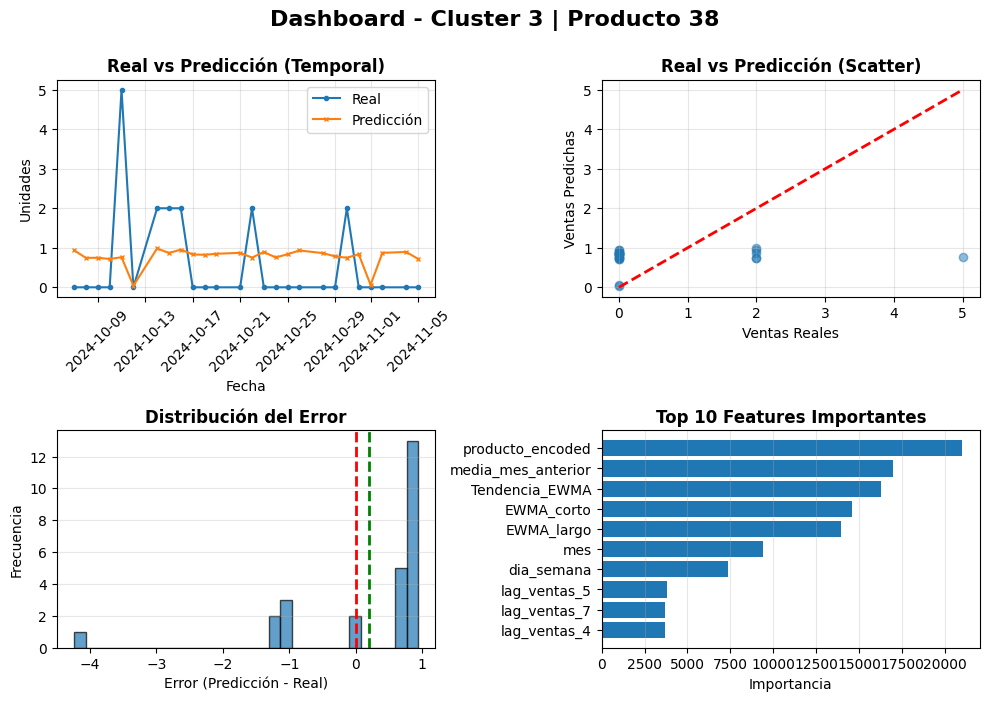

In [12]:
# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: LIGHTGBM POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
        
    lgb_cluster = lgb.LGBMRegressor(**best_params)
    
    lgb_cluster.fit(X_train_c, y_train_c)
    y_pred_c = lgb_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(y_test_c, y_pred_c, f"LightGBM Cluster {cluster}")
    todas_metricas.append(metricas_cluster)
    
    print(f"   ✓ MAE: {metricas_cluster['MAE']:.2f} | RMSE: {metricas_cluster['RMSE']:.2f} | R²: {metricas_cluster['R2']:.4f}")
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz['error'] = y_pred_c - df_test_viz[TARGET]

    grafico_scatter_prediccion(
        df=df_test_viz,
        col_real=TARGET,
        col_pred='prediccion',
        titulo=f'LightGBM Cluster - Real vs Predicción - Cluster {cluster}',
        figsize=(7, 3)
    )

    grafico_feature_importance(
        modelo=lgb_cluster,
        feature_names=FEATURES,
        top_n=len(FEATURES),
        titulo=f'Feature Importance - LightGBM Cluster {cluster}',
        figsize=(7, 5)
    )

    # Crear dataframe con suma por día
    df_daily = df_test_viz.copy()
    df_daily['fecha'] = df_daily['idSecuencia'].dt.date
    df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
    grafico_real_vs_prediccion(
        df=df_daily_sum,
        col_real=TARGET,
        col_pred='prediccion',
        col_fecha='fecha',
        titulo=f'LightGBM - Ventas Diarias Reales vs Predicción Cluster {cluster}',
        figsize=(7, 5)
    )
    
    # Preparar datos para visualización de producto representativo
    test_cluster_pred = test_cluster.copy()
    test_cluster_pred['prediccion'] = y_pred_c
    test_cluster_pred['error'] = y_pred_c - test_cluster_pred[TARGET]
    test_cluster_pred['error_abs'] = np.abs(test_cluster_pred['error'])
    
    # Seleccionar producto representativo
    producto_rep = test_cluster['producto'].value_counts().index[0]
    df_producto = test_cluster_pred[test_cluster_pred['producto'] == producto_rep].copy()
    df_producto = df_producto.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto representativo: {producto_rep} ({len(df_producto)} registros)")
    
    # Estadísticas
    print(f"   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_cluster_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_cluster_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_cluster_pred['error_abs'].max():>8.2f}")
    
    dashboard_prediccion(
        df=df_producto,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=lgb_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster} | Producto {producto_rep}',
        figsize=(10, 7)
    )


# LightGBM por top 10 productos de ventas


🔍 MODELO 3: LIGHTGBM POR PRODUCTO (TOP 10)

🏆 Top 10 productos: [1, 2, 9, 78, 7, 13, 15, 391, 3, 131]

🔄 Entrenando modelo para Producto 1...
   ✓ MAE: 8.37 | RMSE: 12.16 | R²: -0.1913

   📌 Producto 1
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2   11.682678 9.682678   9.682678
    2024-10-08         0    6.397216 6.397216   6.397216
    2024-10-09         5    7.518754 2.518754   2.518754

   📊 Estadísticas del error:
      Error medio:             -2.63
      Error abs medio:          8.37
      Error máximo:            42.74
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 1 8.3684 147.8137 12.1579 -0.1913    117.13      76.32 0.7654    70.87

🏆 Mejor modelo: LightGBM Producto 1 (RMSE: 12.1579)
   ✓ MAE: 8.37 | RMSE: 12.16 | R²: -0.1913

   📌 Producto 1
      Train: 58

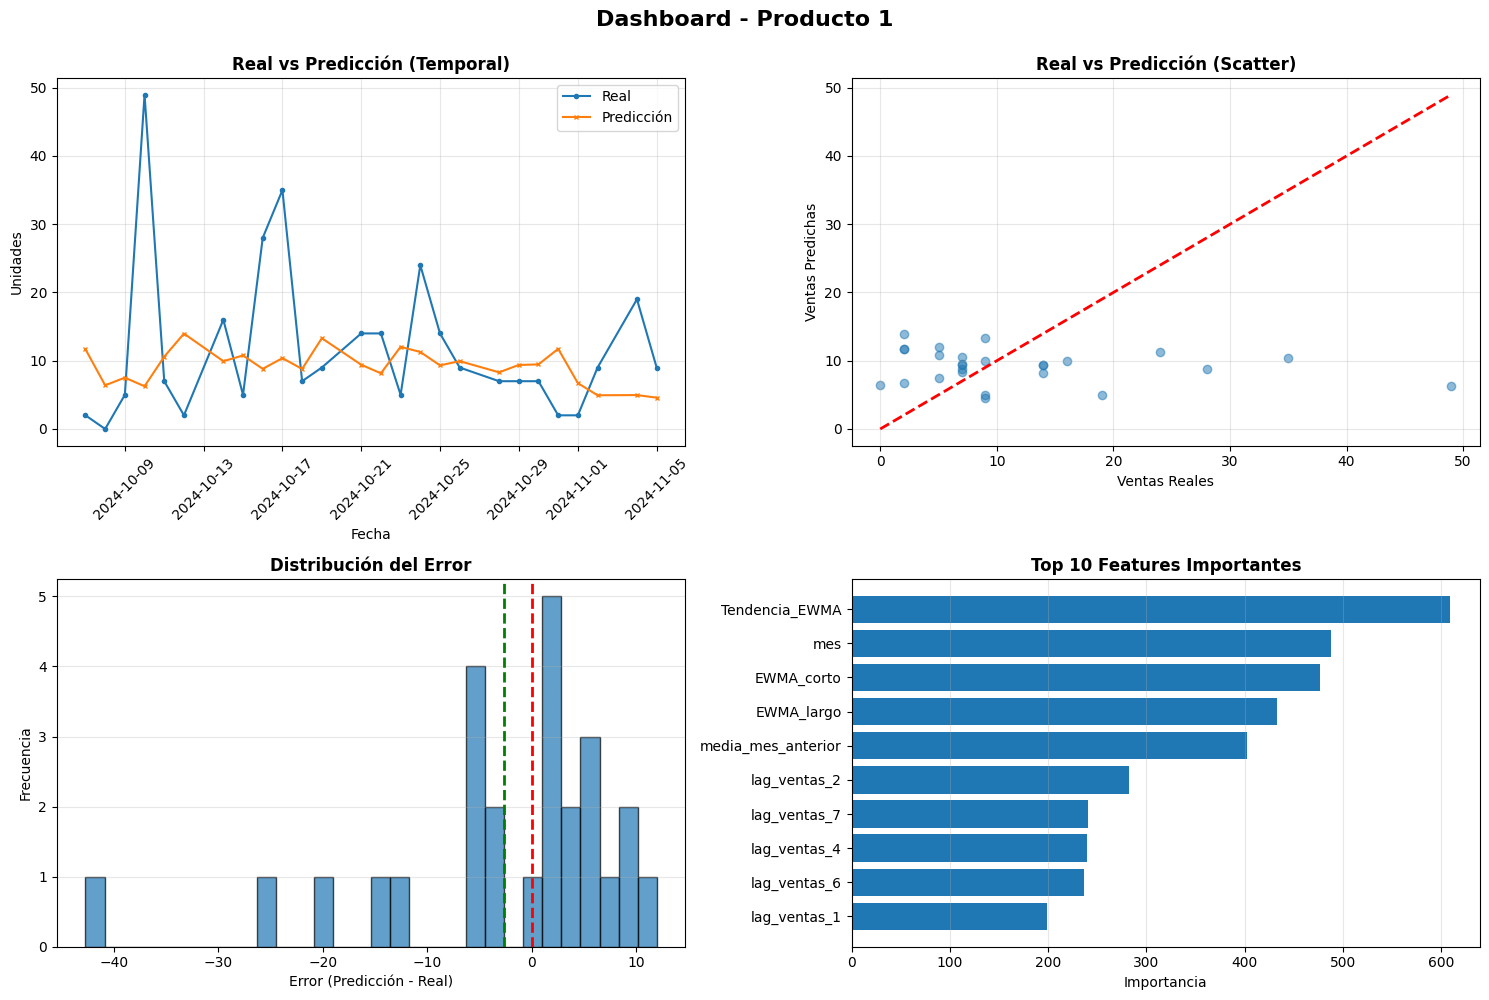


🔄 Entrenando modelo para Producto 2...
   ✓ MAE: 4.00 | RMSE: 5.02 | R²: -0.2336

   📌 Producto 2
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    7.531206  0.531206   0.531206
    2024-10-08         7    6.679673 -0.320327   0.320327
    2024-10-09        16    7.021964 -8.978036   8.978036

   📊 Estadísticas del error:
      Error medio:              1.30
      Error abs medio:          4.00
      Error máximo:             9.52
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 2 3.9957 25.2202 5.022 -0.2336     88.26      67.62 0.6978    63.35

🏆 Mejor modelo: LightGBM Producto 2 (RMSE: 5.0220)


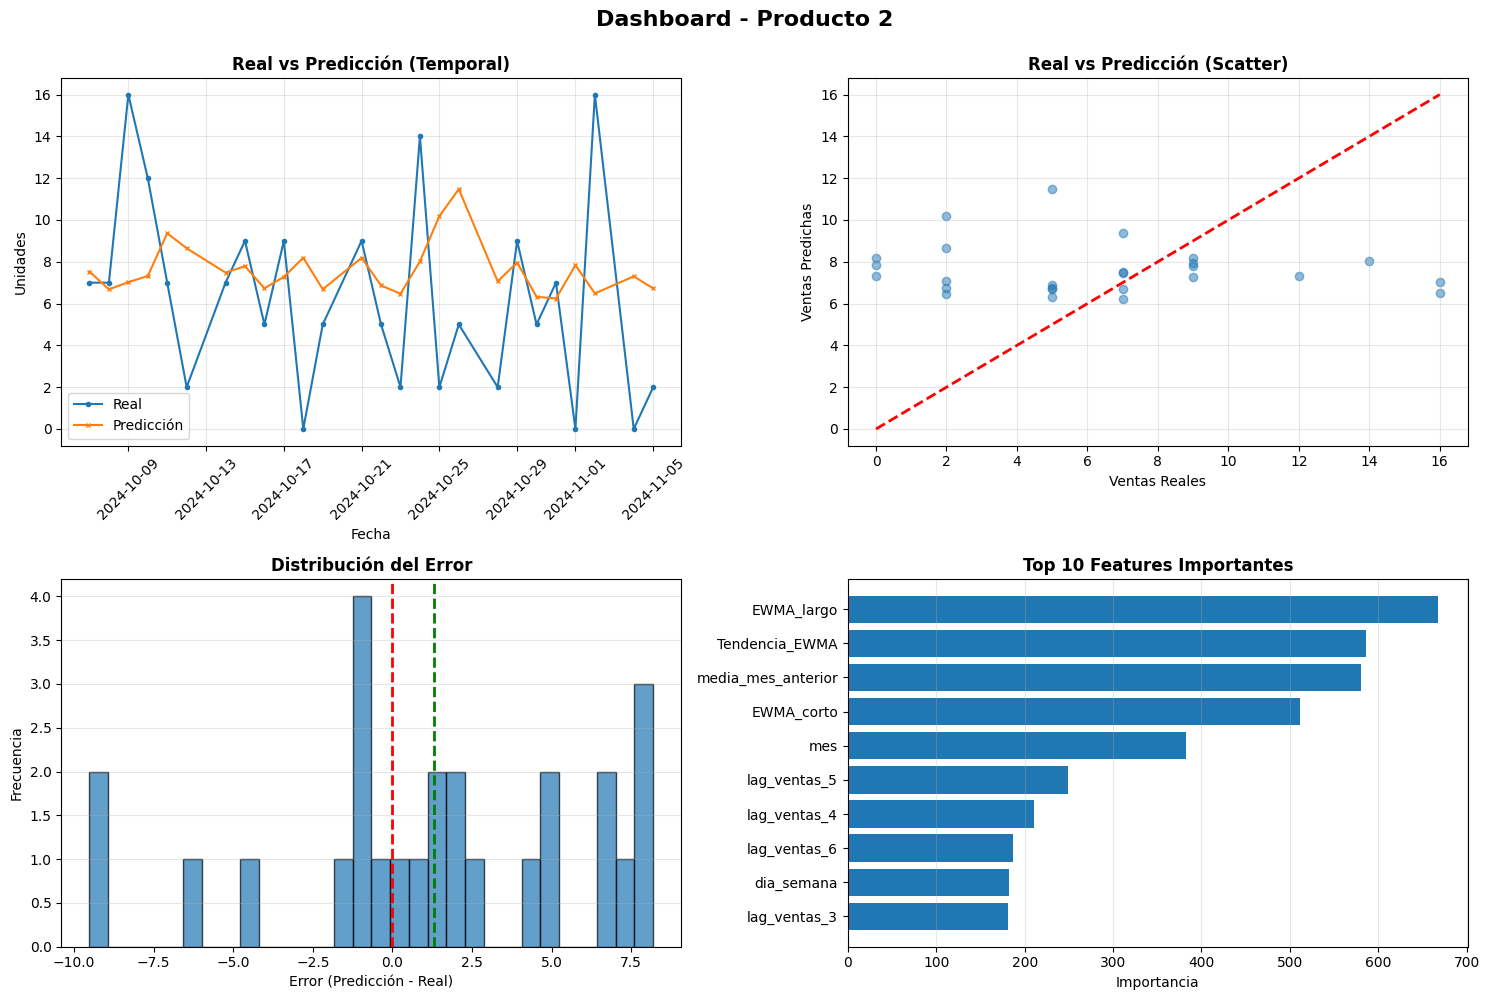


🔄 Entrenando modelo para Producto 9...
   ✓ MAE: 5.26 | RMSE: 5.88 | R²: -0.1229

   📌 Producto 9
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    5.849350 -3.150650   3.150650
    2024-10-08         2    7.904079  5.904079   5.904079
    2024-10-09         5    8.337549  3.337549   3.337549

   📊 Estadísticas del error:
      Error medio:              1.54
      Error abs medio:          5.26
      Error máximo:            10.20
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 9 5.2579 34.5642 5.8791 -0.1229    122.12      87.74 0.7854    81.86

🏆 Mejor modelo: LightGBM Producto 9 (RMSE: 5.8791)


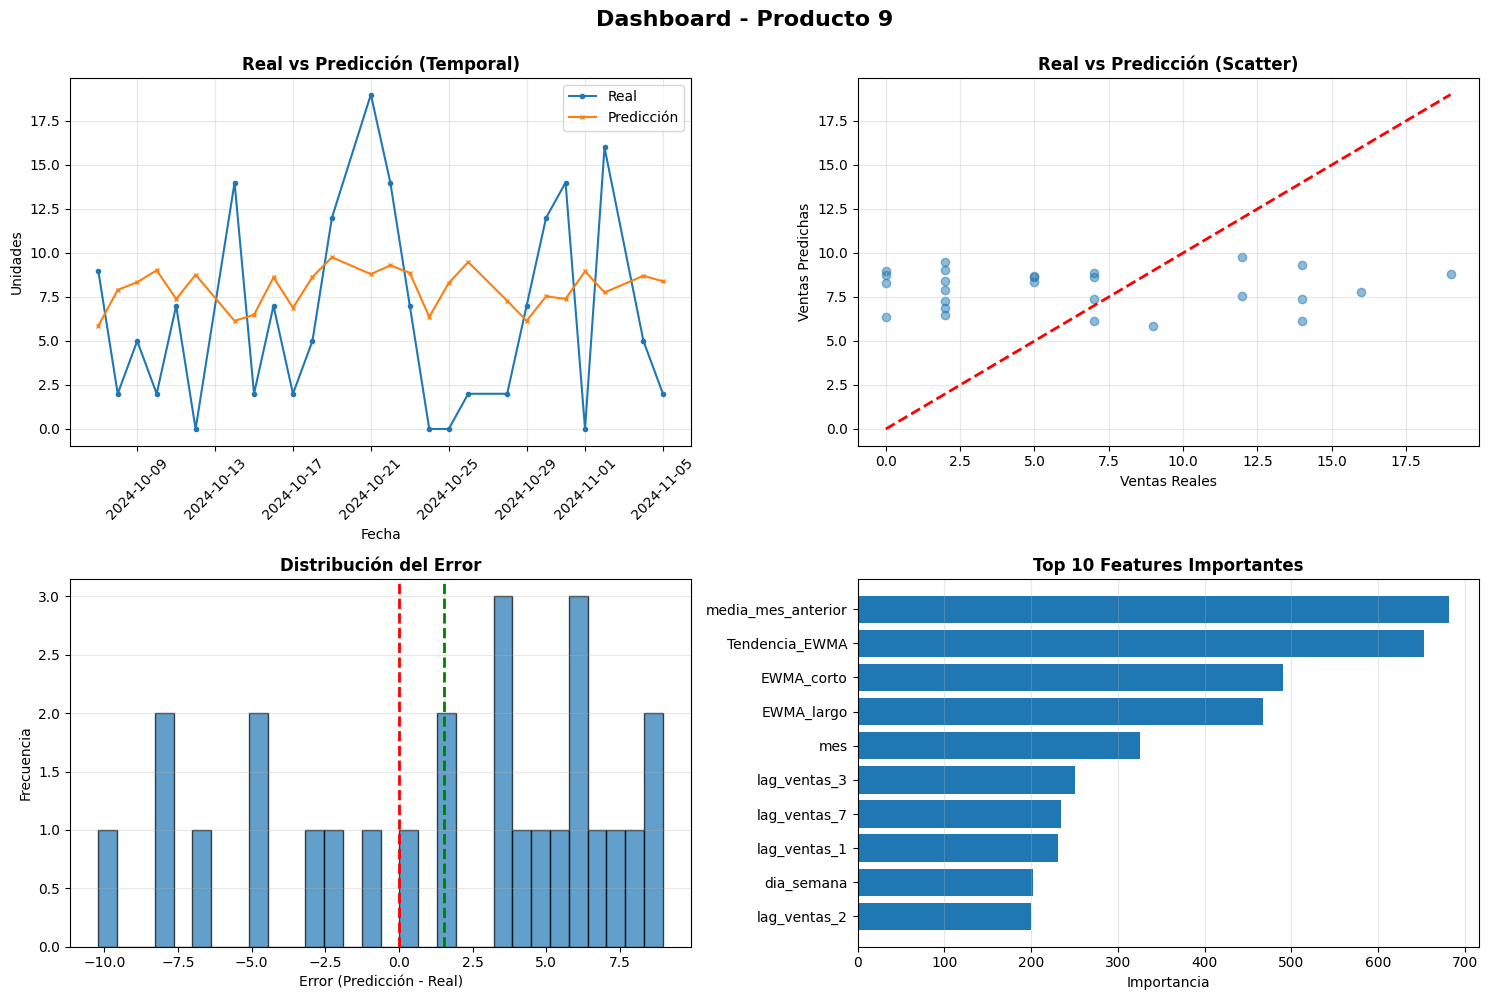


🔄 Entrenando modelo para Producto 78...
   ✓ MAE: 5.66 | RMSE: 7.01 | R²: 0.0406

   📌 Producto 78
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07        16   10.297300 -5.702700   5.702700
    2024-10-08        16    7.605034 -8.394966   8.394966
    2024-10-09        14    9.992022 -4.007978   4.007978

   📊 Estadísticas del error:
      Error medio:             -0.47
      Error abs medio:          5.66
      Error máximo:            19.49
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE   MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 78 5.6597 49.21 7.015 0.0406     70.31      62.85 0.6979    50.05

🏆 Mejor modelo: LightGBM Producto 78 (RMSE: 7.0150)


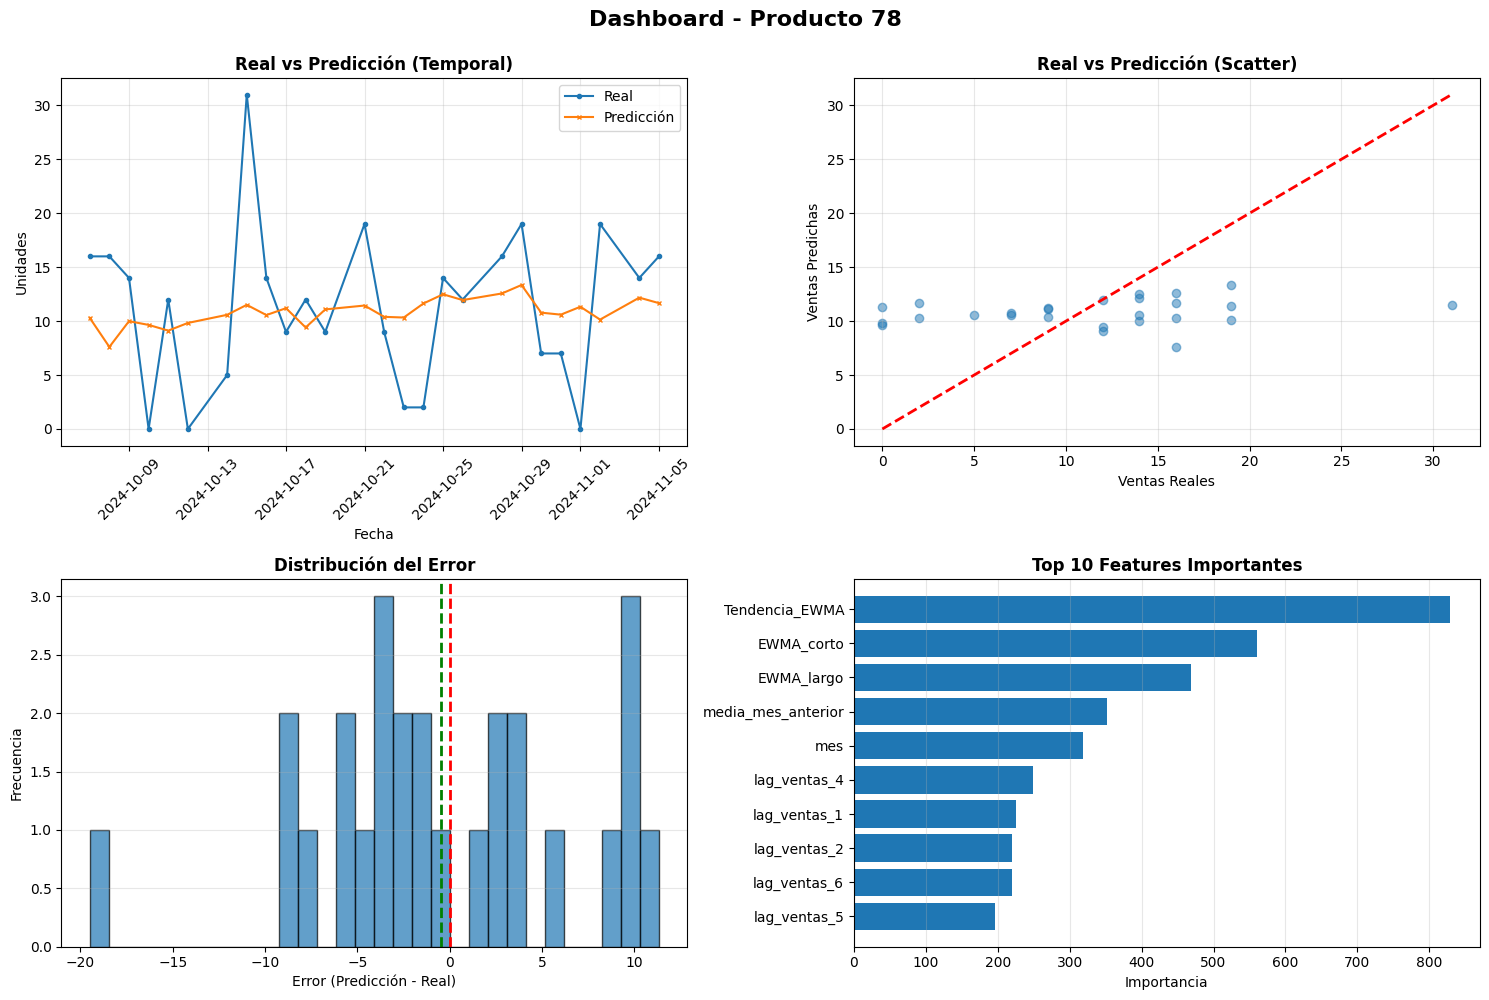


🔄 Entrenando modelo para Producto 7...
   ✓ MAE: 3.36 | RMSE: 3.79 | R²: -0.8646

   📌 Producto 7
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         0    5.652030 5.652030   5.652030
    2024-10-08         0    5.402443 5.402443   5.402443
    2024-10-09         0    4.493410 4.493410   4.493410

   📊 Estadísticas del error:
      Error medio:              2.32
      Error abs medio:          3.36
      Error máximo:             7.64
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo   MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 7 3.364 14.3758 3.7915 -0.8646     91.82     113.58 0.9239   132.52

🏆 Mejor modelo: LightGBM Producto 7 (RMSE: 3.7915)


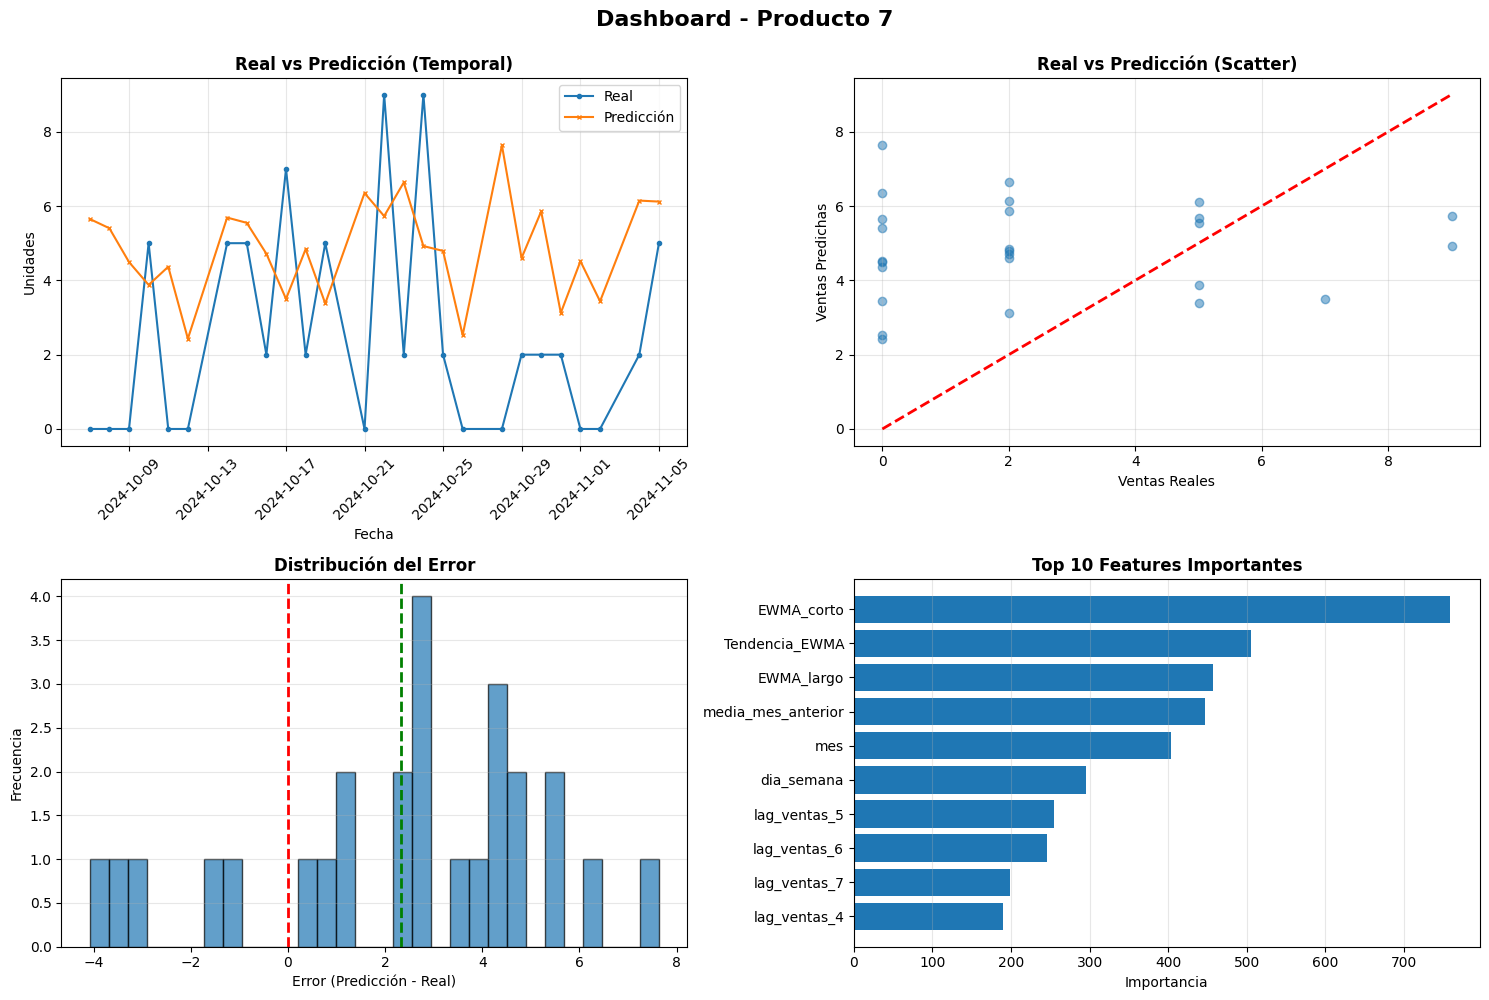


🔄 Entrenando modelo para Producto 13...
   ✓ MAE: 3.41 | RMSE: 3.96 | R²: -0.3555

   📌 Producto 13
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2    5.568976 3.568976   3.568976
    2024-10-08         2    5.678008 3.678008   3.678008
    2024-10-09         2    5.657499 3.657499   3.657499

   📊 Estadísticas del error:
      Error medio:              1.54
      Error abs medio:          3.41
      Error máximo:             9.38
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 13 3.4065 15.6911 3.9612 -0.3555    100.87      84.27 0.7573    85.99

🏆 Mejor modelo: LightGBM Producto 13 (RMSE: 3.9612)


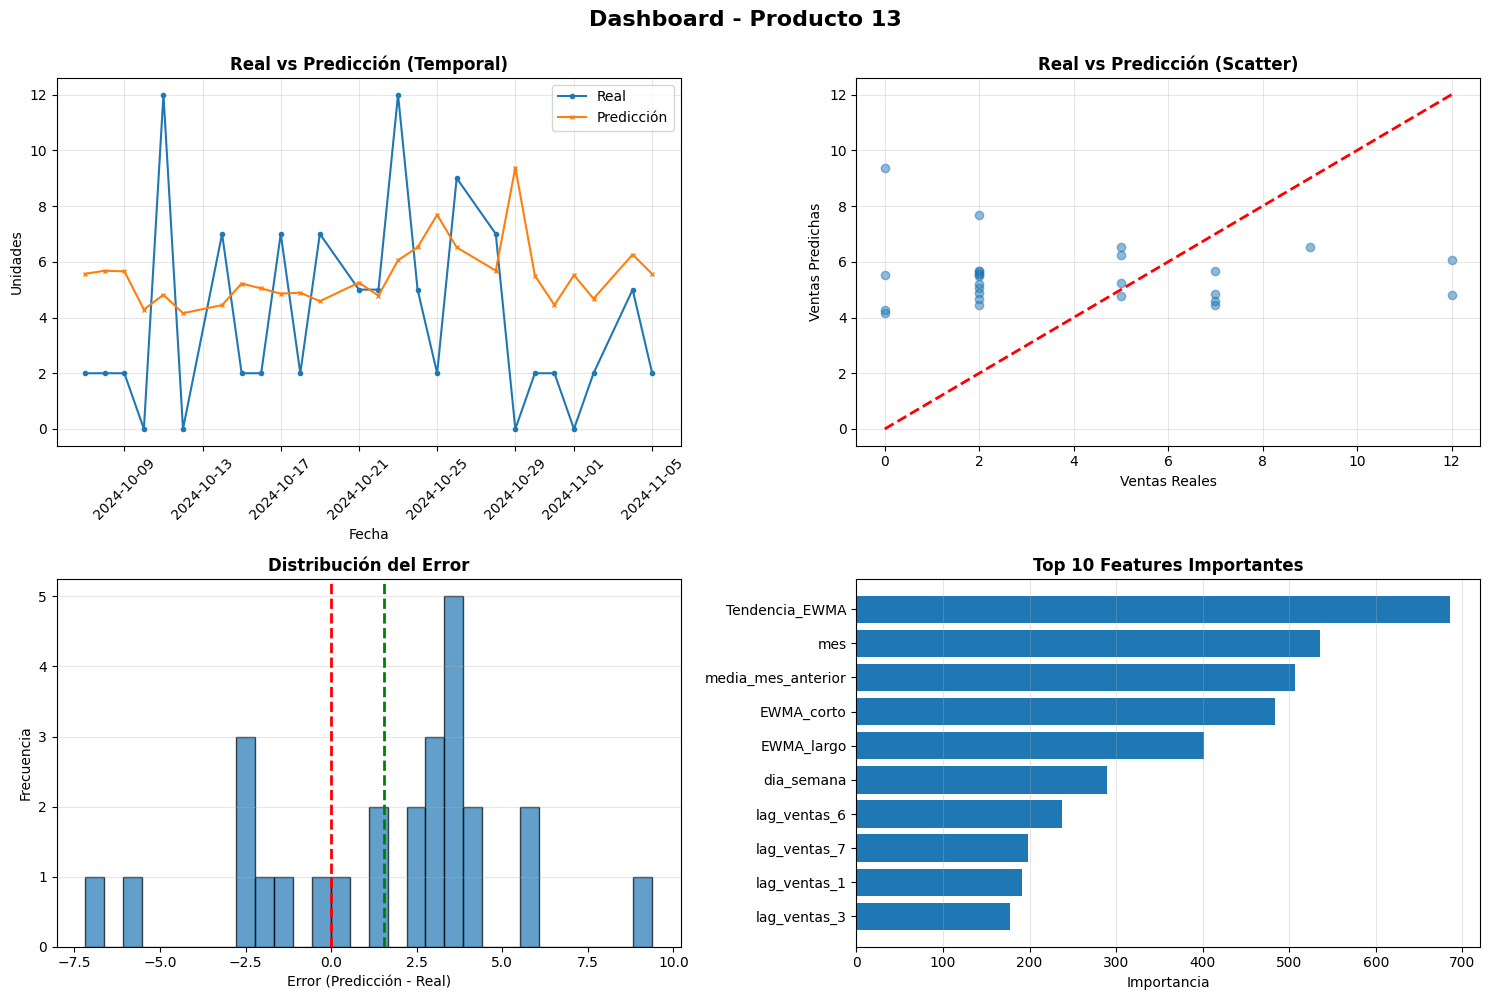


🔄 Entrenando modelo para Producto 15...
   ✓ MAE: 3.70 | RMSE: 4.40 | R²: -0.2132

   📌 Producto 15
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    4.991142 -2.008858   2.008858
    2024-10-08         5    6.654565  1.654565   1.654565
    2024-10-09         9    6.501730 -2.498270   2.498270

   📊 Estadísticas del error:
      Error medio:             -0.04
      Error abs medio:          3.70
      Error máximo:             8.72
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 15 3.6982 19.3899 4.4034 -0.2132     63.73      75.12 0.8437    64.97

🏆 Mejor modelo: LightGBM Producto 15 (RMSE: 4.4034)


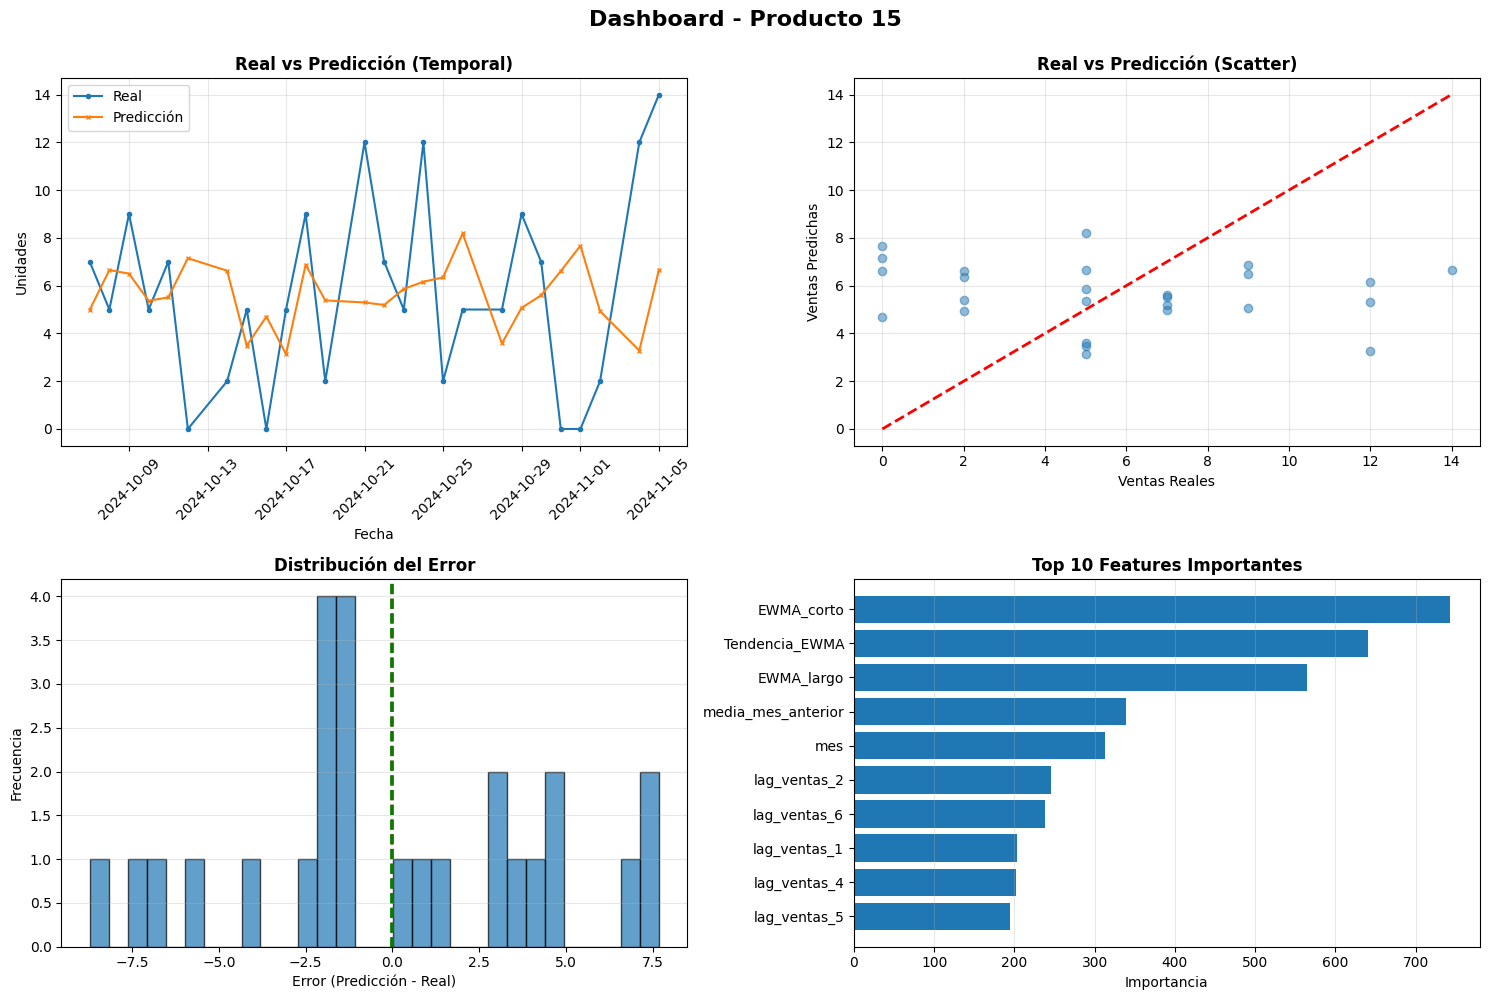


🔄 Entrenando modelo para Producto 391...
   ✓ MAE: 3.26 | RMSE: 3.93 | R²: -0.0931

   📌 Producto 391
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         5    5.748179  0.748179   0.748179
    2024-10-08         9    5.294860 -3.705140   3.705140
    2024-10-09         0    4.282011  4.282011   4.282011

   📊 Estadísticas del error:
      Error medio:              1.46
      Error abs medio:          3.26
      Error máximo:             9.75
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 391 3.2633 15.4781 3.9342 -0.0931     67.97     101.37 0.7003    96.42

🏆 Mejor modelo: LightGBM Producto 391 (RMSE: 3.9342)


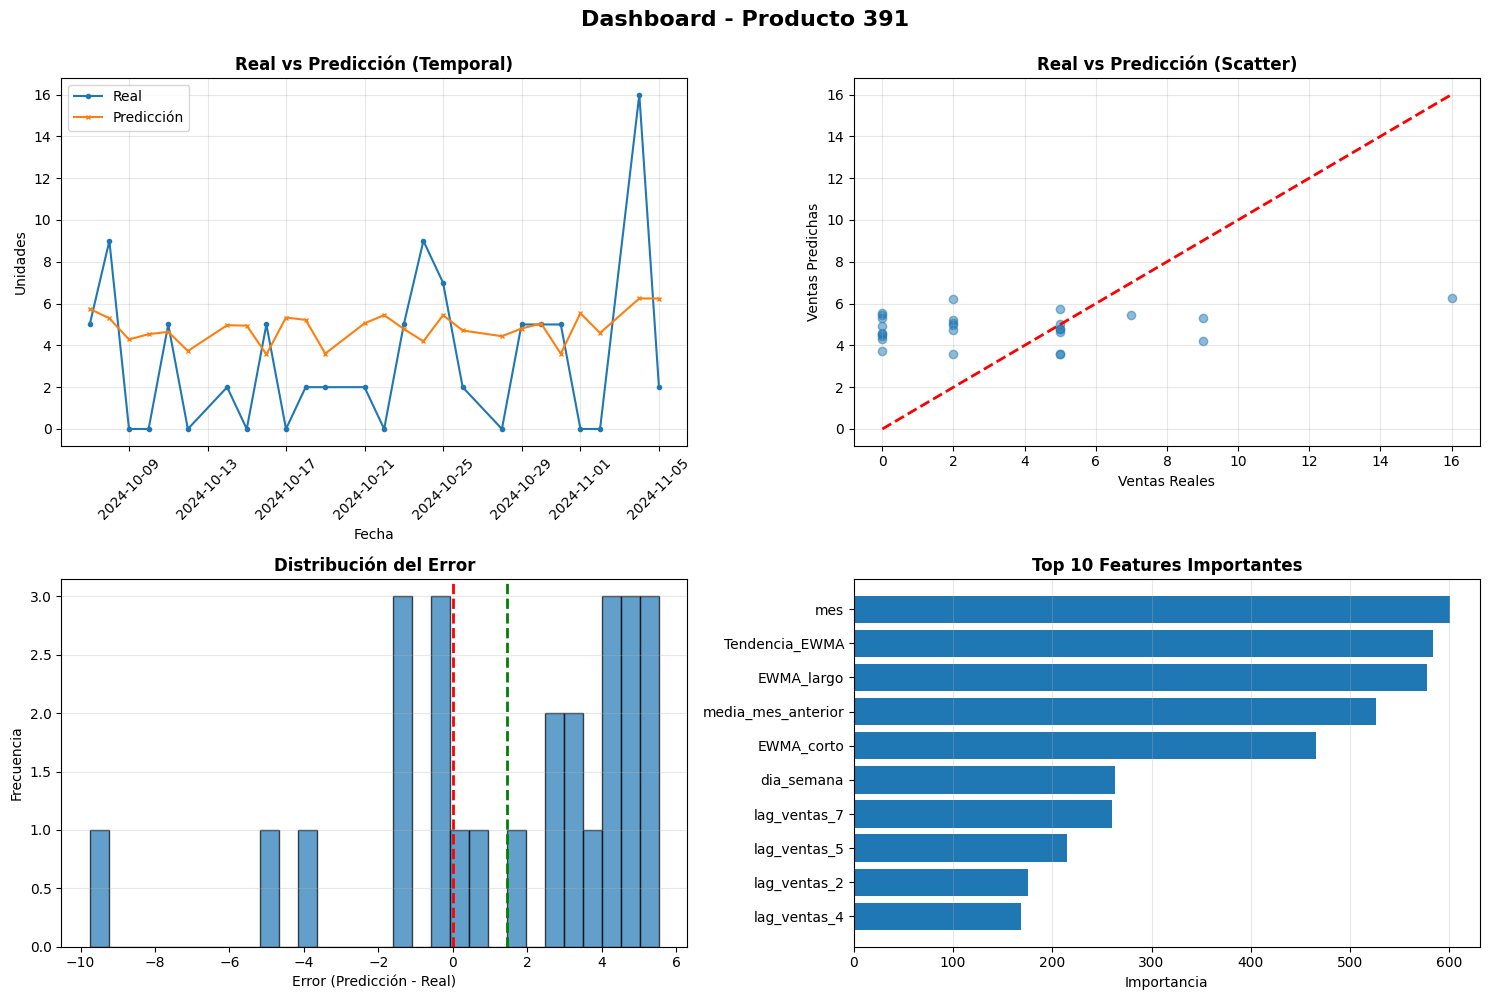


🔄 Entrenando modelo para Producto 3...
   ✓ MAE: 4.61 | RMSE: 5.85 | R²: -0.1290

   📌 Producto 3
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    5.073587 -1.926413   1.926413
    2024-10-08         5    2.524687 -2.475313   2.475313
    2024-10-09         5    3.149350 -1.850650   1.850650

   📊 Estadísticas del error:
      Error medio:             -0.63
      Error abs medio:          4.61
      Error máximo:            14.45
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 3 4.6122 34.2332 5.8509 -0.129      64.8      86.21 0.9918    71.81

🏆 Mejor modelo: LightGBM Producto 3 (RMSE: 5.8509)


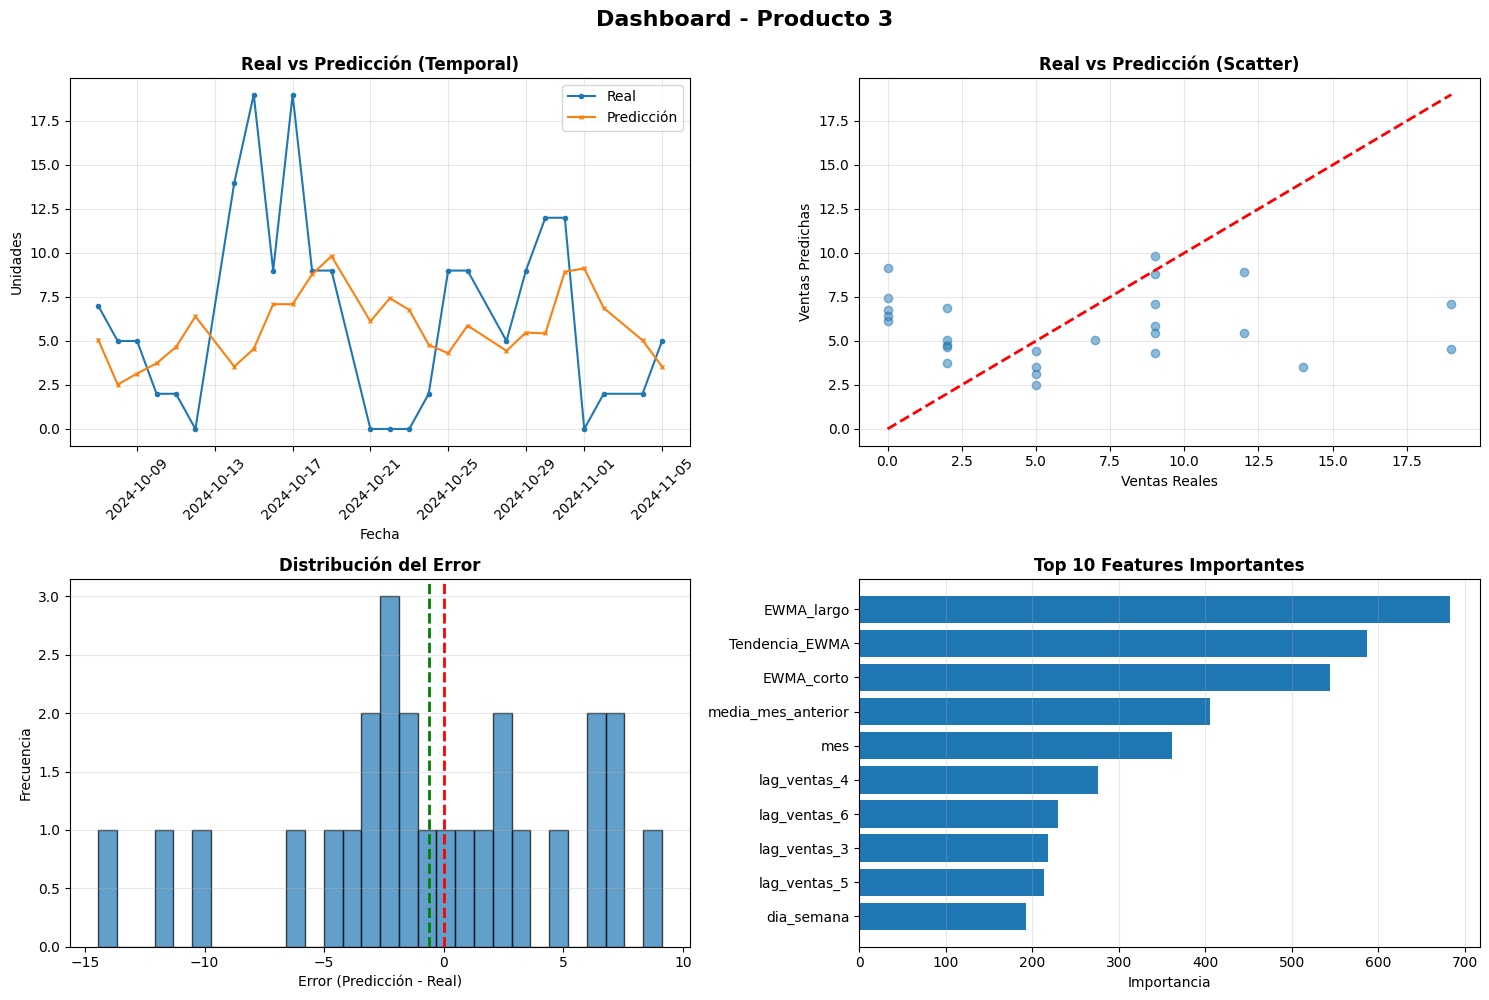


🔄 Entrenando modelo para Producto 131...
   ✓ MAE: 2.99 | RMSE: 3.55 | R²: 0.1545

   📌 Producto 131
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    6.850065 -2.149935   2.149935
    2024-10-08         9    5.908788 -3.091212   3.091212
    2024-10-09         2    7.466504  5.466504   5.466504

   📊 Estadísticas del error:
      Error medio:              0.51
      Error abs medio:          2.99
      Error máximo:             6.33
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 131 2.9867 12.5883 3.548 0.1545     53.97      94.89 0.7001    80.05

🏆 Mejor modelo: LightGBM Producto 131 (RMSE: 3.5480)


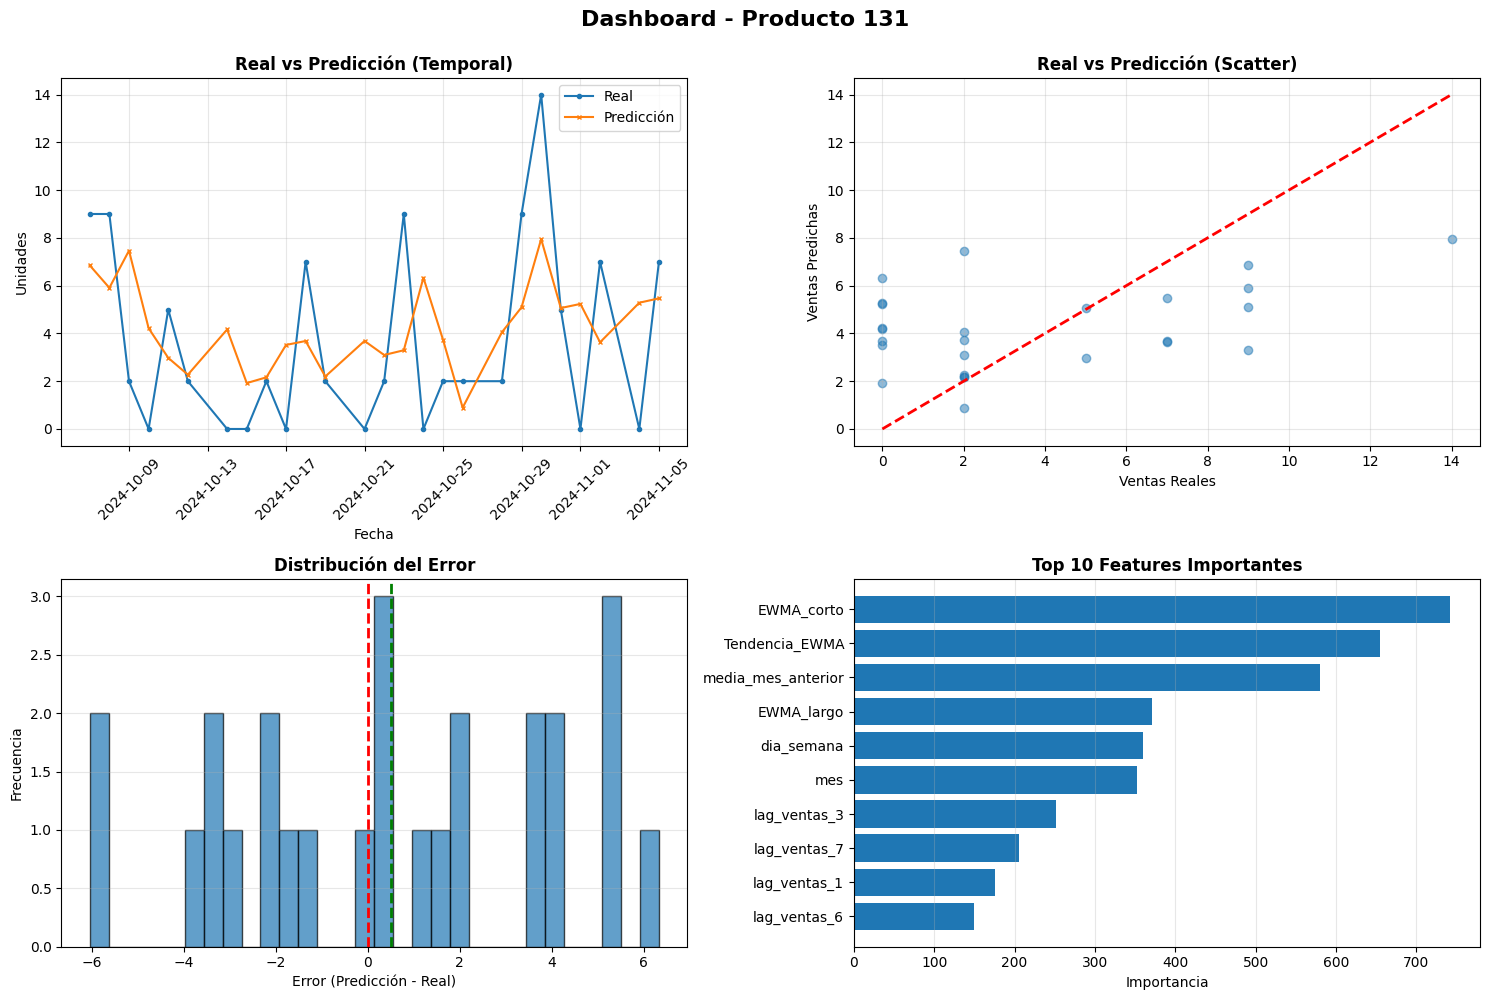

In [13]:
# ============================================================================
# 3. MODELOS POR PRODUCTO (TOP 10)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 3: LIGHTGBM POR PRODUCTO (TOP 10)")
print("="*100)

top_productos = df_train.groupby('producto')['udsVenta'].sum().nlargest(10).index.tolist()
print(f"\n🏆 Top 10 productos: {top_productos}")

modelos_producto = {}

for producto in top_productos:
    print(f"\n🔄 Entrenando modelo para Producto {producto}...")
    
    # Filtrar datos
    train_prod = df_train[df_train['producto'] == producto]
    test_prod = df_test[df_test['producto'] == producto].dropna()
    
    if len(test_prod) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    if len(train_prod) < 100:
        print(f"   ⚠️  Datos insuficientes ({len(train_prod)} registros)")
        continue
    
    X_train_p = train_prod[FEATURES]
    y_train_p = train_prod[TARGET]
    X_test_p = test_prod[FEATURES]
    y_test_p = test_prod[TARGET]
    
    # Entrenar
    lgb_producto = lgb.LGBMRegressor(**best_params)
    
    lgb_producto.fit(X_train_p, y_train_p)
    y_pred_p = lgb_producto.predict(X_test_p)
    
    modelos_producto[producto] = lgb_producto
    
    # Calcular métricas
    metricas_producto = calcular_metricas(y_test_p, y_pred_p, f"LightGBM Producto {producto}")
    todas_metricas.append(metricas_producto)
    
    print(f"   ✓ MAE: {metricas_producto['MAE']:.2f} | RMSE: {metricas_producto['RMSE']:.2f} | R²: {metricas_producto['R2']:.4f}")
    
    # Preparar datos
    test_prod_pred = test_prod.copy()
    test_prod_pred['prediccion'] = y_pred_p
    test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
    test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
    test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / test_prod_pred[TARGET]) * 100
    test_prod_pred = test_prod_pred.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto {producto}")
    print(f"      Train: {len(train_prod)} | Test: {len(test_prod_pred)}")
    
    # Primeras predicciones
    print(f"\n   📋 Primeras 3 predicciones:")
    cols = ['idSecuencia', TARGET, 'prediccion', 'error', 'error_abs']
    print("   " + test_prod_pred[cols].head(3).to_string(index=False).replace('\n', '\n   '))
    
    # Estadísticas
    print(f"\n   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_prod_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_prod_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_prod_pred['error_abs'].max():>8.2f}")
    print(f"      Error % medio:        {test_prod_pred['error_pct'].mean():>8.2f}%")
    
    if len(test_prod_pred) >= 2:
        resumen_metricas([metricas_producto])
        
        try:
            dashboard_prediccion(
                df=test_prod_pred,
                col_fecha='idSecuencia',
                col_real=TARGET,
                col_pred='prediccion',
                modelo=lgb_producto,
                feature_names=FEATURES,
                titulo_principal=f'Dashboard - Producto {producto}',
                figsize=(15, 10),
            )
        except Exception as e:
            print(f"   ⚠️  Error en dashboard: {str(e)}")


# Resumen final


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   LightGBM Cluster 3 1.0850   2.8151  1.6778  0.0567     56.25     169.42 0.7529   133.61
 LightGBM Global Test 1.5688   5.6171  2.3700  0.2670     49.65     144.56 0.7263    96.08
   LightGBM Cluster 0 1.7964   6.5026  2.5500  0.1166     40.00     126.04 0.7330    93.03
LightGBM Producto 131 2.9867  12.5883  3.5480  0.1545     53.97      94.89 0.7001    80.05
   LightGBM Cluster 1 2.7980  13.1163  3.6216  0.1276     56.32      99.42 0.7238    73.38
  LightGBM Producto 7 3.3640  14.3758  3.7915 -0.8646     91.82     113.58 0.9239   132.52
LightGBM Producto 391 3.2633  15.4781  3.9342 -0.0931     67.97     101.37 0.7003    96.42
 LightGBM Producto 13 3.4065  15.6911  3.9612 -0.3555    100.87      84.27 0.7573    85.99
 LightGBM Producto 15 3.6982  19.3899  4.4034 -0.2132     63.73      75.

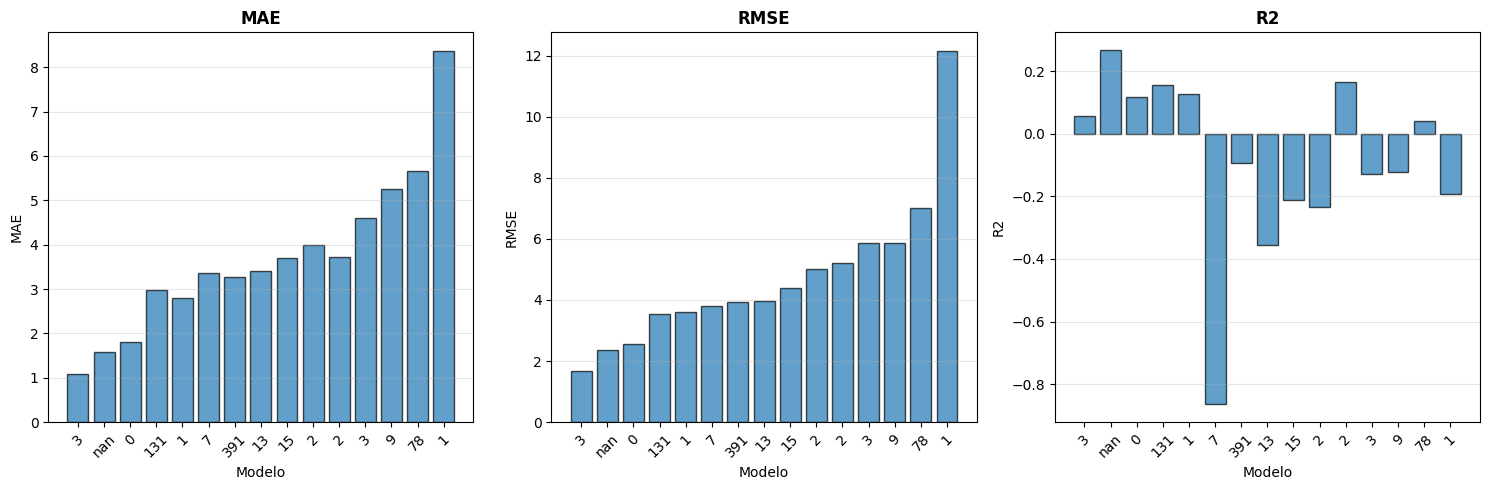


📊 ANÁLISIS POR CATEGORÍAS DE MODELOS

🌐 MODELOS GLOBALES:
           Algoritmo    MAE  RMSE    R2
LightGBM Global Test 1.5688  2.37 0.267

   Promedio RMSE: 2.37

🎯 MODELOS POR CLUSTER:
         Algoritmo    MAE   RMSE     R2
LightGBM Cluster 3 1.0850 1.6778 0.0567
LightGBM Cluster 0 1.7964 2.5500 0.1166
LightGBM Cluster 1 2.7980 3.6216 0.1276
LightGBM Cluster 2 3.7241 5.1993 0.1646

   Promedio RMSE: 3.26
   Mejor cluster: LightGBM Cluster 3 (RMSE: 1.68)
   Peor cluster: LightGBM Cluster 2 (RMSE: 5.20)

🛒 MODELOS POR PRODUCTO:
            Algoritmo    MAE    RMSE      R2
LightGBM Producto 131 2.9867  3.5480  0.1545
  LightGBM Producto 7 3.3640  3.7915 -0.8646
LightGBM Producto 391 3.2633  3.9342 -0.0931
 LightGBM Producto 13 3.4065  3.9612 -0.3555
 LightGBM Producto 15 3.6982  4.4034 -0.2132
  LightGBM Producto 2 3.9957  5.0220 -0.2336
  LightGBM Producto 3 4.6122  5.8509 -0.1290
  LightGBM Producto 9 5.2579  5.8791 -0.1229
 LightGBM Producto 78 5.6597  7.0150  0.0406
  LightGBM Prod

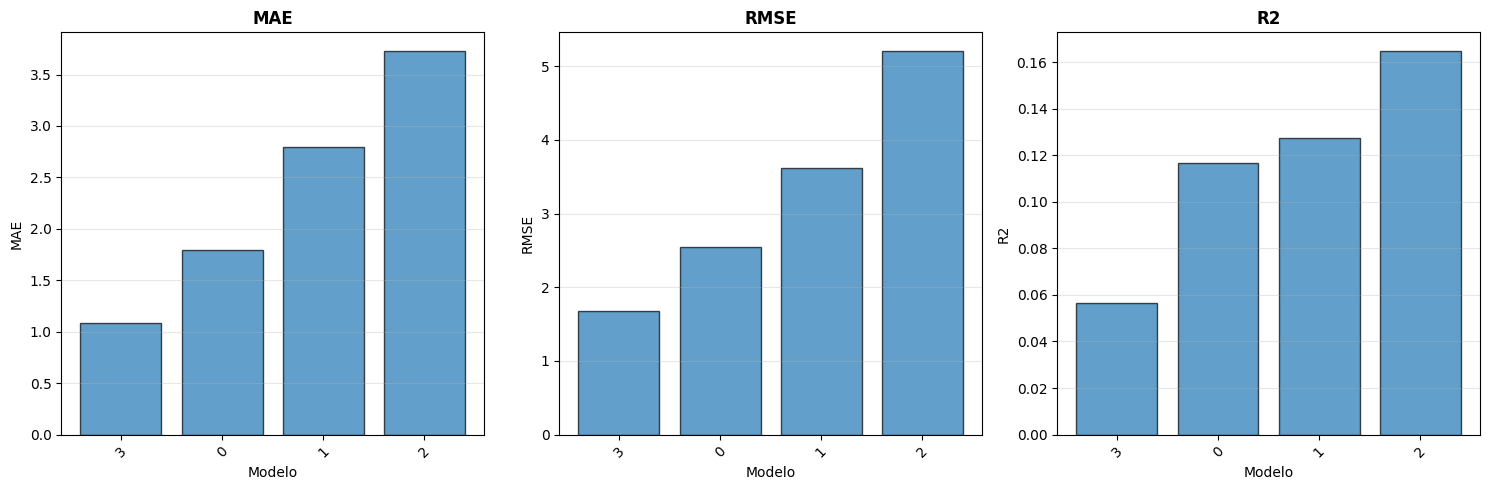


📊 Comparación entre productos:


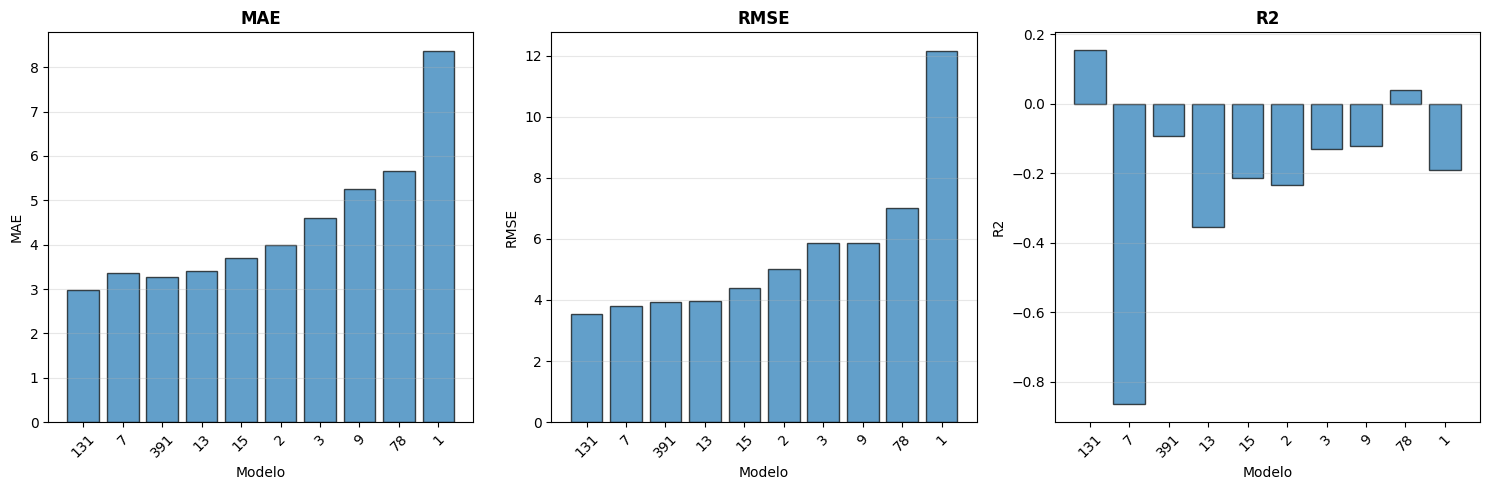


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Total de modelos evaluados: 15
   - Modelos globales: 1
   - Modelos por cluster: 4
   - Modelos por producto: 10


In [14]:
# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Mostrar tabla completa de métricas
    print("\n📊 Resumen de todas las métricas:")
    resumen_metricas(todas_metricas)
    
    # Comparar métricas
    df_comparacion_final = comparar_metricas(todas_metricas, ordenar_por='RMSE')
    
    print("\n" + "="*100)
    print("📈 RANKING DE MODELOS POR RMSE")
    print("="*100)
    print(df_comparacion_final[['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].to_string(index=False))
    
    # Gráfico comparativo de TODOS los modelos
    print("\n📊 Generando gráficos comparativos...")
    grafico_comparacion_metricas(df_comparacion_final, metricas=['MAE', 'RMSE', 'R2'])
    
    # Análisis por categorías
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS")
    print("="*100)
    
    # Separar por tipo de modelo
    df_global = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Global')]
    df_clusters = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Cluster')]
    df_productos = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Producto')]
    
    print("\n🌐 MODELOS GLOBALES:")
    if len(df_global) > 0:
        print(df_global[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_global['RMSE'].mean():.2f}")
    
    print("\n🎯 MODELOS POR CLUSTER:")
    if len(df_clusters) > 0:
        print(df_clusters[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_clusters['RMSE'].mean():.2f}")
        print(f"   Mejor cluster: {df_clusters.iloc[0]['Algoritmo']} (RMSE: {df_clusters.iloc[0]['RMSE']:.2f})")
        print(f"   Peor cluster: {df_clusters.iloc[-1]['Algoritmo']} (RMSE: {df_clusters.iloc[-1]['RMSE']:.2f})")
    
    print("\n🛒 MODELOS POR PRODUCTO:")
    if len(df_productos) > 0:
        print(df_productos[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_productos['RMSE'].mean():.2f}")
        print(f"   Mejor producto: {df_productos.iloc[0]['Algoritmo']} (RMSE: {df_productos.iloc[0]['RMSE']:.2f})")
        print(f"   Peor producto: {df_productos.iloc[-1]['Algoritmo']} (RMSE: {df_productos.iloc[-1]['RMSE']:.2f})")
    
    # Mejor modelo general
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]
    
    print(f"\n🏆 {mejor_modelo['Algoritmo']}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    
    # Gráficos comparativos por categoría
    if len(df_clusters) > 1:
        print("\n📊 Comparación entre clusters:")
        grafico_comparacion_metricas(df_clusters, metricas=['MAE', 'RMSE', 'R2'])
    
    if len(df_productos) > 1:
        print("\n📊 Comparación entre productos:")
        grafico_comparacion_metricas(df_productos, metricas=['MAE', 'RMSE', 'R2'])
    
else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if 'Global' in m['Algoritmo']])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if 'Cluster' in m['Algoritmo']])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if 'Producto' in m['Algoritmo']])}")

# Salvar resultados

In [15]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
# Guardar con un nombre distintivo para LightGBM
df_resultados.to_csv('datos/resultados_metricas_lightgbm.csv', index=False)
print("Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'")

Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'
